# Fine-Tuning

# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from datasets import Dataset
from peft import LoraConfig, TaskType
import xgboost as xgb
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2026-05-06 11:30:30.379308: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 11:30:30.898558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/dkusmenko/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving

In [2]:
import os
# This enables memory fragmentation handling specifically for AMD HIP
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
def print_gpu_utilization():
    if not torch.cuda.is_available():
        print("No GPU detected.")
        return

    # On AMD ROCm, 'cuda' functions query the HIP backend
    reserved = torch.cuda.memory_reserved()
    allocated = torch.cuda.memory_allocated()
    total_memory = torch.cuda.get_device_properties(0).total_memory
    
    print(f"Total GPU Mem: {total_memory / 1024**3:.2f} GB")
    print(f"Reserved (Cached): {reserved / 1024**3:.2f} GB")
    print(f"Allocated (Active): {allocated / 1024**3:.2f} GB")
    print(f"Free (Approx): {(total_memory - reserved) / 1024**3:.2f} GB")
    print("-" * 30)

# Run it
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 0.00 GB
Allocated (Active): 0.00 GB
Free (Approx): 15.82 GB
------------------------------


/home/dkusmenko/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:736: UserWarning: Can't initialize amdsmi - Error code: 34
  warnings.warn(f"Can't initialize amdsmi - Error code: {e.err_code}")


# Data Import, Clean, and Sample

In [4]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Load in freMTPL2freq dataset
dataset = fetch_openml(data_id=41214, as_frame=True)
full_df = dataset.frame

# Clean basic types first
full_df['ClaimNb'] = pd.to_numeric(full_df['ClaimNb'])
full_df['Exposure'] = pd.to_numeric(full_df['Exposure'])
full_df['Exposure'] = full_df['Exposure'].clip(upper=1.0)
full_df['Frequency'] = full_df['ClaimNb'] / full_df['Exposure']

# mapping for contextualized factors
brand_mapping = {'B1': 'Renault, Nissan, or Citroen', 'B2': 'Renault, Nissan, or Citroen',
                 'B3': 'Volkswagen, Audi, Skoda, or Seat', 'B4': 'Opel, General Motors, or Ford',
                 'B5': 'Opel, General Motors, or Ford','B6': 'Fiat', 'B10':'Mercedes, Chrysler, or BMW',
                 'B11':'Mercedes, Chrysler, or BMW', 'B12': 'Japanese (except Nissan) or Korean', 'B13': 'Other','B14': 'Other' }

region_mapping = {
    "R11": "Île-de-France",
    "R21": "Champagne-Ardenne",
    "R22": "Picardie",
    "R23": "Haute-Normandie",
    "R24": "Centre",
    "R25": "Basse-Normandie",
    "R26": "Bourgogne",
    "R31": "Nord–Pas-de-Calais",
    "R41": "Lorraine",
    "R42": "Alsace",
    "R43": "Franche–Comté",
    "R52": "Pays de la Loire",
    "R53": "Bretagne",
    "R54": "Poitou–Charentes",
    "R72": "Aquitaine",
    "R73": "Midi–Pyrénées",
    "R74": "Limousin",
    "R82": "Rhône–Alpes",
    "R83": "Auvergne",
    "R91": "Languedoc–Roussillon",
    "R93": "Provence–Alpes–Côte d’Azur",
    "R94": "Corse"
}

area_mapping = {
    "A": "rural area",
    "B": "semi-rural area",
    "C": "suburban-fringe area",
    "D": "suburban area",
    "E": "urban area",
    "F": "urban center"
}

gas_mapping = {
    "'Diesel'": "Diesel",
    "'Regular'": "Regular"

}

full_df["VehBrand"] = full_df["VehBrand"].map(brand_mapping)
full_df["Region"] = full_df["Region"].map(region_mapping)
full_df["Area"] = full_df["Area"].map(area_mapping)
full_df["VehGas"] = full_df["VehGas"].map(gas_mapping)


In [5]:
# Load the split indices
df_splits = pd.read_csv('freMTPL2freq_split_indices.csv')

# Ensure IDpol is the same type in both dataframes for a clean merge
full_df['IDpol'] = full_df['IDpol'].astype(int)
df_splits['IDpol'] = df_splits['IDpol'].astype(int)

# Merge the dataset with the split indicators
# We use a left join to keep the original data rows
df_merged = full_df.merge(df_splits, on='IDpol', how='left')

# Create the subsets based on the indicator columns
train_df = df_merged[df_merged['is_train'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
test_df = df_merged[df_merged['is_test'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()
finetune_df = df_merged[df_merged['is_finetune'] == 1].drop(columns=['is_train', 'is_test', 'is_finetune']).copy()

# Print results
print(f"Total rows: {len(full_df)}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Finetune rows: {len(finetune_df)}")

full_df['has_claim'] = full_df['ClaimNb'] > 0
test_df['has_claim'] = test_df['ClaimNb'] > 0

subset_df, _ = train_test_split(
    test_df, 
    train_size=1000, 
    stratify=test_df['has_claim'], # <--- Guarantees representative risk profile
    random_state=42
)

print(f"Stratified Subset Size: {len(subset_df)}")
print(f"Claim Rate in Subset: {subset_df['has_claim'].mean():.4f}")
print(f"Claim Rate in Full Data: {full_df['has_claim'].mean():.4f} (Should match)")

# Inspect the subset
print(subset_df.head())

Total rows: 678013
Train rows: 500000
Test rows: 100000
Finetune rows: 76782
Stratified Subset Size: 1000
Claim Rate in Subset: 0.0510
Claim Rate in Full Data: 0.0502 (Should match)
          IDpol  ClaimNb  Exposure                  Area  VehPower  VehAge  \
99790   1019129        0      0.33            rural area         7      15   
445970  3171204        2      0.62         suburban area         7       6   
234357  2074453        0      1.00         suburban area         5       8   
422402  3133764        0      0.49            urban area         5      14   
642975  6009772        0      0.03  suburban-fringe area         8       2   

        DrivAge  BonusMalus                            VehBrand   VehGas  \
99790        78          50         Renault, Nissan, or Citroen  Regular   
445970       27         100    Volkswagen, Audi, Skoda, or Seat  Regular   
234357       71          50         Renault, Nissan, or Citroen  Regular   
422402       26          85         Renault, 

# Create Prompts

In [6]:
# ==========================================
# 2. SERIALIZATION (Tabular -> Text)
# ==========================================

def serialize_row(row):
    """
    Converts a row of insurance covariates into a natural language prompt.
    Uses a fixed template for consistency between Training and Inference.
    """
    # Handling categorical values cleanly
    veh_brand = str(row['VehBrand']).strip()
    veh_gas = str(row['VehGas']).strip()
    area = str(row['Area']).strip()
    region = str(row['Region']).strip()
    
    return (f"""You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information:
- Policyholder Age: {row['DrivAge']} years old (in France people can drive starting at age 18)
- Land Type: {area}
- Region: {region}, France
- Population density: {row['Density']} people/km2 (average density is 1792 people/km2)
- Vehicle: {veh_brand}
- Vehicle Age: {row['VehAge']} years old
- Fuel type: {veh_gas} (either Diesel or Regular Gasoline)
- Power class: {row['VehPower']} (min = 4, max = 15)
- Bonus-Malus score: {row['BonusMalus']} (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)"""
    )

def serialize_row_black(row):
    """
    Converts a row of insurance covariates into a natural language prompt.
    Uses a fixed template for consistency between Training and Inference.
    """
    # Handling categorical values cleanly
    veh_brand = str(row['VehBrand']).strip()
    veh_gas = str(row['VehGas']).strip()
    area = str(row['Area']).strip()
    region = str(row['Region']).strip()
    
    return (f"""You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information:
- Policyholder Age: {row['DrivAge']} years old (in France people can drive starting at age 18)
- Land Type: {area}
- Region: {region}, France
- Population density: {row['Density']} people/km2 (average density is 1792 people/km2)
- Vehicle: {veh_brand}
- Vehicle Age: {row['VehAge']} years old
- Fuel type: {veh_gas} (either Diesel or Regular Gasoline)
- Power class: {row['VehPower']} (min = 4, max = 15)
- Bonus-Malus score: {row['BonusMalus']} (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)
- Race: Black"""
    )

def serialize_row_white(row):
    """
    Converts a row of insurance covariates into a natural language prompt.
    Uses a fixed template for consistency between Training and Inference.
    """
    # Handling categorical values cleanly
    veh_brand = str(row['VehBrand']).strip()
    veh_gas = str(row['VehGas']).strip()
    area = str(row['Area']).strip()
    region = str(row['Region']).strip()
    
    return (f"""You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information:
- Policyholder Age: {row['DrivAge']} years old (in France people can drive starting at age 18)
- Land Type: {area}
- Region: {region}, France
- Population density: {row['Density']} people/km2 (average density is 1792 people/km2)
- Vehicle: {veh_brand}
- Vehicle Age: {row['VehAge']} years old
- Fuel type: {veh_gas} (either Diesel or Regular Gasoline)
- Power class: {row['VehPower']} (min = 4, max = 15)
- Bonus-Malus score: {row['BonusMalus']} (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)
- Race: White"""
    )

# Apply serialization

subset_df['text_desc_no_aug'] = subset_df.apply(serialize_row, axis=1)

subset_df['text_desc_black'] = subset_df.apply(serialize_row_black, axis=1)

subset_df['text_desc_white'] = subset_df.apply(serialize_row_white, axis=1)


### Example Prompt

You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information:
- Policyholder Age: 78 years old (in France people can drive starting at age 18)
- Land Type: rural area
- Region: Poitou–Charentes, France
- Population density: 43 people/km2 (average density is 1792 people/km2)
- Vehicle: Renault, Nissan, or Citroen
- Vehicle Age: 15 years old
- Fuel type: Regular (either Diesel or Regular Gasoline)
- Power class: 7 (min = 4, max = 15)
- Bonus-Malus score: 50 (scored between 50 and 230 with entrance level 100, <100 means bonus, >100 means malus)

# Downsteam GLM

# Using Fine-Tuned Model (after training)

In [7]:
# Initialize Model
model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B", 
    trust_remote_code=True, 
    device="cuda",
    model_kwargs={
        "torch_dtype": torch.float16,   # Critical for speed/VRAM
        "attn_implementation": "sdpa"   # Faster attention
    }
)

# Load & Merge
model.load_adapter(".adapters/qwen-finetuned-freMTPL")

`torch_dtype` is deprecated! Use `dtype` instead!
/home/dkusmenko/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1329: UserWarning: expandable_segments not supported on this platform (Triggered internally at /pytorch/c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


In [8]:
# Test Model works
print("Model loaded successfully!")
with model.truncate_sentence_embeddings(truncate_dim=64):
    embeddings_truncated = model.encode(["hello there", "hiya"])
assert embeddings_truncated.shape[-1] == 64

Model loaded successfully!


/usr/lib/python3.10/contextlib.py:103: FutureWarning: The `truncate_sentence_embeddings` method has been renamed to `truncate_embeddings`.
  self.gen = func(*args, **kwds)
/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:256.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:302.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [9]:
embeddings_truncated

array([[-0.02197 , -0.00644 , -0.00995 , -0.05048 ,  0.00621 , -0.00899 ,
        -0.03012 ,  0.03244 , -0.09186 ,  0.013405,  0.002062, -0.03452 ,
         0.1089  , -0.00871 , -0.04977 ,  0.08264 , -0.02393 ,  0.05362 ,
         0.10815 , -0.0865  ,  0.0405  ,  0.011475, -0.0431  ,  0.1299  ,
        -0.004837, -0.01064 , -0.03041 ,  0.0998  ,  0.01363 , -0.009125,
         0.02342 ,  0.02632 , -0.01054 ,  0.001483, -0.03574 , -0.012665,
        -0.01157 , -0.00482 , -0.02876 ,  0.05807 , -0.01811 ,  0.02663 ,
         0.075   , -0.02109 ,  0.003563, -0.0325  ,  0.04803 , -0.01186 ,
         0.000534, -0.01155 , -0.02774 , -0.02225 ,  0.00668 ,  0.004898,
         0.00836 , -0.0577  ,  0.05264 ,  0.001372,  0.04315 , -0.00405 ,
        -0.09357 ,  0.0341  , -0.01917 ,  0.01162 ],
       [-0.005592,  0.01398 , -0.01559 , -0.05893 ,  0.0352  , -0.02773 ,
         0.00419 ,  0.0995  , -0.0797  ,  0.01047 , -0.00509 ,  0.004272,
         0.1124  , -0.01446 , -0.08057 ,  0.07697 , -0.0342

Model is outputting embeddings of dim 64

### Check VRAM Usage

In [10]:
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 1.22 GB
Allocated (Active): 1.11 GB
Free (Approx): 14.60 GB
------------------------------


Now want to generate embeddings from data

Ensure model is running on GPU

In [11]:
print(model.device)

cuda:0


In [12]:
import torch

# 1. Define the device (On AMD ROCm, we still call it 'cuda' in PyTorch)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Moving model to: {device}")

# 2. Move the model
model = model.to(device)

Moving model to: cuda


In [13]:
print("Generating embeddings for GLM...")

embeddings_no_aug = model.encode(subset_df['text_desc_no_aug'].tolist(), batch_size=64, show_progress_bar=True)

embeddings_black = model.encode(subset_df['text_desc_black'].tolist(), batch_size=64, show_progress_bar=True)

embeddings_white = model.encode(subset_df['text_desc_white'].tolist(), batch_size=64, show_progress_bar=True)

Generating embeddings for GLM...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

/home/dkusmenko/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:736: UserWarning: Can't initialize amdsmi - Error code: 34
  warnings.warn(f"Can't initialize amdsmi - Error code: {e.err_code}")


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [14]:
import numpy as np

# Save everything in one single archive
np.savez(
    "embeddings/embeddings_finetuned_no_aug.npz", 
    X=embeddings_no_aug,           # The Features (Embeddings)
    y=subset_df['ClaimNb'].values, # The Target (Counts)
    w=subset_df['Exposure'].values # The Weight (Exposure)
)
print("Saved all training data to embeddings/embeddings_finetuned_no_aug.npz")

np.savez(
    "embeddings/embeddings_finetuned_black.npz", 
    X=embeddings_black,           # The Features (Embeddings)
    y=subset_df['ClaimNb'].values, # The Target (Counts)
    w=subset_df['Exposure'].values # The Weight (Exposure)
)

print("Saved all testing data to embeddings/embeddings_finetuned_black.npz")

np.savez(
    "embeddings/embeddings_finetuned_white.npz", 
    X=embeddings_white,           # The Features (Embeddings)
    y=subset_df['ClaimNb'].values, # The Target (Counts)
    w=subset_df['Exposure'].values # The Weight (Exposure)
)

print("Saved all testing data to embeddings/embeddings_finetuned_white.npz")

Saved all training data to embeddings/embeddings_finetuned_no_aug.npz
Saved all testing data to embeddings/embeddings_finetuned_black.npz
Saved all testing data to embeddings/embeddings_finetuned_white.npz


In [4]:
import numpy as np
no_aug_df = np.load("embeddings/embeddings_finetuned_no_aug.npz")

black_df = np.load("embeddings/embeddings_finetuned_black.npz")

white_df = np.load("embeddings/embeddings_finetuned_white.npz")

train_df = np.load("embeddings/train_embeddings.npz")

In [5]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

def mean_cosine_distance(base_df, diff_df1, diff_df2):
    """
    Compute the mean cosine distance between a base embedding dataframe
    and two difference embedding dataframes.
    
    Returns a dictionary with the mean cosine distance for each pair.
    """
    base = base_df
    
    results = {}
    for name, diff_df in [("base_vs_black", diff_df1), ("base_vs_white", diff_df2)]:
        pairwise_distances = cdist(base, diff_df, metric="cosine")
        results[name] = pairwise_distances.mean()
    
    return results

results = mean_cosine_distance(no_aug_df['X'], black_df['X'], white_df['X'])
for pair, dist in results.items():
    print(f"{pair}: {dist:.6f}")

base_vs_black: 0.019782
base_vs_white: 0.019500


Want to have embeddings -- claim count -- exposure

In [6]:
meta_train = [train_df['y'], train_df['w']]

In [7]:
# Partition Data
X_train = train_df['X']
meta_train = [train_df['y'], train_df['w']]

meta_train = pd.DataFrame({
    'ClaimNb': meta_train[0],
    'Exposure': meta_train[1]
})


X_test_no_aug = no_aug_df['X']
meta_test_no_aug = [no_aug_df['y'], no_aug_df['w']]

meta_test_no_aug = pd.DataFrame({
    'ClaimNb': meta_test_no_aug[0],
    'Exposure': meta_test_no_aug[1]
})

X_test_black = black_df['X']
meta_test_black = [black_df['y'], black_df['w']]

meta_test_black = pd.DataFrame({
    'ClaimNb': meta_test_black[0],
    'Exposure': meta_test_black[1]
})

X_test_white = white_df['X']
meta_test_white = [white_df['y'], white_df['w']]

meta_test_white = pd.DataFrame({
    'ClaimNb': meta_test_white[0],
    'Exposure': meta_test_white[1]
})

# Setup Scaler & PCA with Pandas Output
scaler = StandardScaler().set_output(transform='pandas')
pca = PCA(n_components=48).set_output(transform='pandas')

# Pipeline Execution
# TRAIN: Fit & Transform
# Scaler returns a DF with index preserved -> PCA returns a DF with index preserved
X_train_scaled = scaler.fit_transform(X_train)
X_train_pca = pca.fit_transform(X_train_scaled)

# TEST: Transform Only
X_test_scaled_no_aug = scaler.transform(X_test_no_aug)
X_test_pca_no_aug = pca.transform(X_test_scaled_no_aug)

X_test_scaled_black = scaler.transform(X_test_black)
X_test_pca_black = pca.transform(X_test_scaled_black)

X_test_scaled_white = scaler.transform(X_test_white)
X_test_pca_white = pca.transform(X_test_scaled_white)

# Reconstruction
# Because indices are preserved, pandas aligns rows automatically.
# We can also rename columns cleanly if we want "PC1" instead of "pca0"

# Rename columns from 'pca0' to 'PC1', 'PC2'...
new_col_names = [f"PC{i+1}" for i in range(48)]
X_train_pca.columns = new_col_names
X_test_pca_no_aug.columns = new_col_names

X_test_pca_black.columns = new_col_names

X_test_pca_white.columns = new_col_names

# Concatenate (Join)
final_train = pd.concat([X_train_pca, meta_train], axis=1)
final_test_no_aug = pd.concat([X_test_pca_no_aug, meta_test_no_aug], axis=1)

final_test_black = pd.concat([X_test_pca_black, meta_test_black], axis=1)

final_test_white = pd.concat([X_test_pca_white, meta_test_white], axis=1)

print(f"Original Predictors: {len(X_train)}")
print(f"Reduced Predictors:  {X_train_pca.shape[1]}")
print(f"Final Train Shape:   {final_train.shape}")
print(final_train.head())

Original Predictors: 500000
Reduced Predictors:  48
Final Train Shape:   (500000, 50)
         PC1       PC2       PC3        PC4        PC5       PC6        PC7  \
0  62.870514  1.518155 -2.982116  -5.957392   1.868471  8.585588  11.517632   
1  19.945080  8.927476 -3.151282 -10.800955  -0.576052  7.142439 -18.704068   
2  19.995651  9.021616 -3.199520 -10.846554  -0.589172  7.175472 -18.819900   
3 -10.743790  5.903749  3.569325  -8.626901  -2.509558 -0.578815  -0.876561   
4  15.952578  2.698232 -2.170221  -8.848677 -10.090970  2.469301 -16.459459   

        PC8       PC9      PC10  ...      PC41      PC42      PC43      PC44  \
0 -2.777123 -1.033204 -3.826737  ...  2.056090 -0.993526 -4.569236 -4.240988   
1  2.182124 -4.743923  7.908948  ...  0.633132 -3.959050 -1.548871  3.679846   
2  2.136222 -4.729541  7.905344  ...  0.628739 -4.001403 -1.499705  3.672552   
3 -4.197455  0.441616  0.386404  ... -0.204174  3.531083 -0.750709  0.890539   
4 -2.250129  8.179672 -4.863892  ...  1

In [8]:
import statsmodels.api as sm

# Add constant (intercept) to PCA features
X_train_glm = sm.add_constant(X_train_pca)
X_test_glm_no_aug  = sm.add_constant(X_test_pca_no_aug)

X_test_glm_black  = sm.add_constant(X_test_pca_black)

X_test_glm_white  = sm.add_constant(X_test_pca_white)

# Fit Poisson GLM with Exposure offset
# offset = log(Exposure) is standard for claim frequency modelling
offset_train = np.log(final_train['Exposure'])
offset_test_no_aug  = np.log(final_test_no_aug['Exposure'])

offset_test_black  = np.log(final_test_black['Exposure'])

offset_test_white  = np.log(final_test_white['Exposure'])

poisson_model = sm.GLM(
    final_train['ClaimNb'],
    X_train_glm,
    family=sm.families.Poisson(),
    offset=offset_train
).fit()

print(poisson_model.summary())

# Predict on test set (returns expected claim counts)
y_pred_no_aug = poisson_model.predict(X_test_glm_no_aug, offset=offset_test_no_aug)

y_pred_black = poisson_model.predict(X_test_glm_black, offset=offset_test_black)

y_pred_white = poisson_model.predict(X_test_glm_white, offset=offset_test_white)

# Evaluate: Poisson deviance is the standard metric for claim frequency models
from sklearn.metrics import mean_poisson_deviance

y_test_no_aug = final_test_no_aug['ClaimNb']
exp_test_no_aug = final_test_no_aug['Exposure']

y_test_black = final_test_black['ClaimNb']
exp_test_black = final_test_black['Exposure']

y_test_white = final_test_white['ClaimNb']
exp_test_white = final_test_white['Exposure']

# Predicted frequency (claims per unit exposure) for deviance calculation
freq_pred_no_aug = y_pred_no_aug / exp_test_no_aug
freq_actual_no_aug = y_test_no_aug / exp_test_no_aug

deviance_no_aug = mean_poisson_deviance(freq_actual_no_aug, freq_pred_no_aug)
print(f"Mean Poisson Deviance for No Race Augmentation: {deviance_no_aug:.6f}")

freq_pred_black = y_pred_black / exp_test_black
freq_actual_black = y_test_black / exp_test_black

deviance_black = mean_poisson_deviance(freq_actual_black, freq_pred_black)
print(f"Mean Poisson Deviance for Race: Black: {deviance_black:.6f}")

freq_pred_white = y_pred_white / exp_test_white
freq_actual_white = y_test_white / exp_test_white

deviance_white = mean_poisson_deviance(freq_actual_white, freq_pred_white)

print(f"Mean Poisson Deviance for Race: White: {deviance_white:.6f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               500000
Model:                            GLM   Df Residuals:                   499951
Model Family:                 Poisson   Df Model:                           48
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0172e+05
Date:                Wed, 06 May 2026   Deviance:                   1.5263e+05
Time:                        11:31:21   Pearson chi2:                 1.13e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02290
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3758      0.007   -354.531      0.0

In [9]:
from scipy import stats
import pandas as pd

def compare_predictions(base_preds, aug_preds, aug_name):
    t_stat, p_val = stats.ttest_rel(base_preds, aug_preds)
    return {
        "Comparison":   f"Base vs {aug_name}",
        "Base Mean":    base_preds.mean(),
        "Base Std":     base_preds.std(),
        "Aug Mean":     aug_preds.mean(),
        "Aug Std":      aug_preds.std(),
        "Mean Diff":    (aug_preds - base_preds).mean(),
        "t-statistic":  t_stat,
        "p-value":      p_val
    }

results = pd.DataFrame([
    compare_predictions(freq_pred_no_aug, freq_pred_black, "Race: Black"),
    compare_predictions(freq_pred_no_aug, freq_pred_white, "Race: White"),
])

print(results.to_string(index=False))

         Comparison  Base Mean  Base Std  Aug Mean  Aug Std  Mean Diff  t-statistic      p-value
Base vs Race: Black   0.112018  0.113332  0.096480 0.082733  -0.015538    15.230265 2.941413e-47
Base vs Race: White   0.112018  0.113332  0.095651 0.083461  -0.016367    16.506219 2.627521e-54


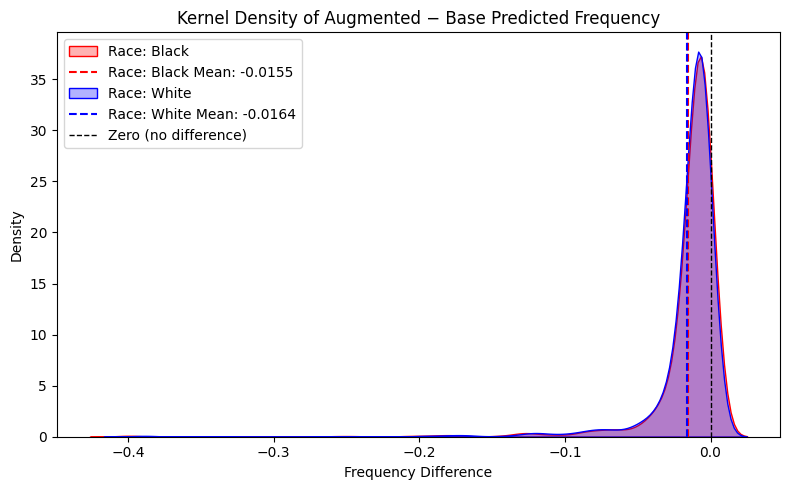

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

diff_black = freq_pred_black - freq_pred_no_aug
diff_white = freq_pred_white - freq_pred_no_aug

fig, ax = plt.subplots(figsize=(8, 5))

for diff, name, color in zip(
    [diff_black, diff_white],
    ["Race: Black", "Race: White"],
    ["red", "blue"]
):
    sns.kdeplot(diff, ax=ax, color=color, fill=True, alpha=0.3, label=name)
    ax.axvline(diff.mean(), color=color, linestyle="--", linewidth=1.5, label=f"{name} Mean: {diff.mean():.4f}")

ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Zero (no difference)")
ax.set_title("Kernel Density of Augmented − Base Predicted Frequency")
ax.set_xlabel("Frequency Difference")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()